# C-00 — Por que é possível computar com um qubit?

- **Trilha:** Núcleo da QC
- **Milestone:** 0 — Intuição antes do formalismo

<div style="border-left: 2px solid #6b7280; padding: 0.5em 1em 0.5em 1.1em; margin: 0.8em 0 1.2em 0; background: rgba(107, 114, 128, 0.05); border-radius: 0 3px 3px 0;">
  <span style="font-size: 0.65em; font-weight: 700; letter-spacing: 0.13em; text-transform: uppercase; color: #9ca3af;">Etimologia </span><br>
  
  <span style="font-size: 0.88em; line-height: 1.65;"> <b>Abstração</b> vem do latim <i>abstractio</i>, de <i>abstrahere</i>: <i>ab-</i> (“para fora”) + <i>trahere</i> (“puxar”, “arrastar”). A ideia original é a de puxar algo para fora de um contexto, separando-o do resto. Por isso, abstrair é deixar de lado os detalhes particulares para reter apenas o que importa numa certa perspectiva. Então, no fundo, “abstração” carrega a ideia de isolar uma estrutura essencial para poder pensar, descrever ou operar sobre ela com mais clareza.</span>

  <span style="font-size: 0.88em; line-height: 1.65;"> <b>Computar</b> vem do latim computare com- (“junto”, “em conjunto”) + putare (“calcular”, “avaliar”, “contar”, e originalmente até “podar”, no sentido de limpar para apurar). A ideia original é a de contar ou calcular reunindo elementos. Depois, o termo ganhou o sentido mais técnico de processar informação segundo regras. Então, no fundo, “computar” carrega a ideia de transformar algo em resultado por meio de um procedimento bem definido.</span>

  <span style="font-size: 0.88em; line-height: 1.65;"> <b>Superposição</b> vem do latim <i>superpositio</i>, de <i>superponere</i>: <i>super-</i> (“sobre”) + <i>ponere</i> (“colocar”, “pôr”). A ideia original é a de colocar uma coisa sobre outra, de modo que ocupem a mesma posição ou se acumulem. Em termos gerais, descreve a combinação ou sobreposição de elementos, efeitos ou descrições em um mesmo espaço ou estrutura. Então, no fundo, “superposição” carrega a ideia de coexistência organizada — múltiplos componentes presentes ao mesmo tempo, compondo um todo.</span>

</div>


## Afirmação introdutória

Eu consigo computar com um `qubit` porque, dado um problema, posso `codificar as soluções` candidatas em `superposição` e aplicar `operações unitárias` que fazem as `amplitudes interferirem` entre si de modo que, na medição, a resposta correta seja favorecida.

Neste notebook, vamos discutir só essas duas linhas. Me comprometo a fazer você entende-las profundamente aqui.

## 1. O que é um Qubit?

Um qubit é uma abstração de um sistema físico que possui dois estados distinguíveis. Cada estado é descrito por uma amplitude de probabilidade. Essas amplitudes são números que podem ser positivos, negativos ou complexos, e o módulo ao quadrado de cada uma dá a probabilidade de obter aquele estado numa medição.

── Estado no ar (superposição) ──────────────────────────────
  |moeda⟩ = α·|cara⟩ + β·|coroa⟩
  |moeda⟩ = 0.8660·|cara⟩ + 0.5000·|coroa⟩
  |α|² + |β|² = 0.75 + 0.25 = 1.00  ✓

── Probabilidades (após medir — a moeda cai) ─────────────────
  P(cara)  = |α|² = 75%
  P(coroa) = |β|² = 25%


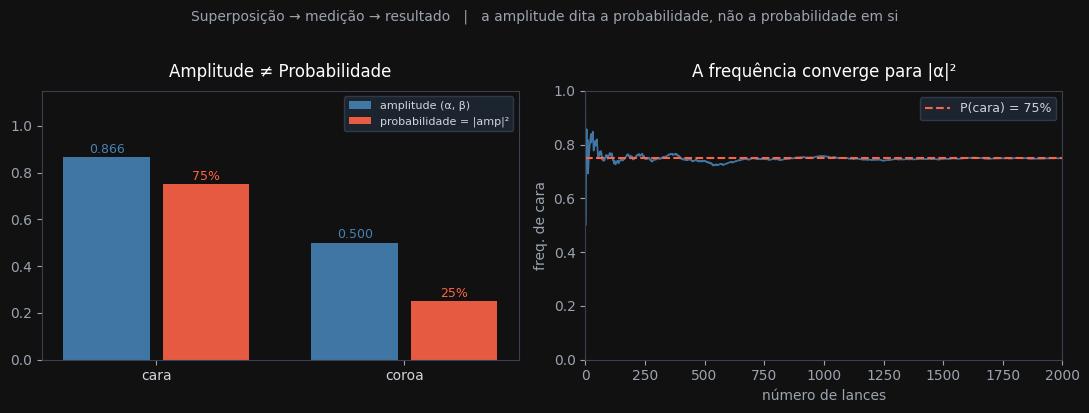

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Estado da moeda no ar (superposição) ────────────────────────────────────
# α e β são amplitudes de probabilidade — não probabilidades diretas.
# A probabilidade de cada face é |amplitude|².
alpha = np.sqrt(0.75)   # amplitude de cara   →  P(cara)  = |α|² = 0.75
beta  = np.sqrt(0.25)   # amplitude de coroa  →  P(coroa) = |β|² = 0.25

assert np.isclose(alpha**2 + beta**2, 1.0), "estado inválido"

print("── Estado no ar (superposição) ──────────────────────────────")
print(f"  |moeda⟩ = α·|cara⟩ + β·|coroa⟩")
print(f"  |moeda⟩ = {alpha:.4f}·|cara⟩ + {beta:.4f}·|coroa⟩")
print(f"  |α|² + |β|² = {alpha**2:.2f} + {beta**2:.2f} = {alpha**2 + beta**2:.2f}  ✓")
print()
print("── Probabilidades (após medir — a moeda cai) ─────────────────")
print(f"  P(cara)  = |α|² = {alpha**2:.0%}")
print(f"  P(coroa) = |β|² = {beta**2:.0%}")

# ── Simulação de lances ──────────────────────────────────────────────────────
np.random.seed(42)
n = 2000
resultados = np.random.choice([0, 1], size=n, p=[alpha**2, beta**2])  # 0=cara, 1=coroa

# ── Visualização ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor='#111')
fig.patch.set_facecolor('#111')

for ax in axes:
    ax.set_facecolor('#111')
    ax.tick_params(colors='#9ca3af')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# Gráfico 1 — amplitude vs. probabilidade
ax1 = axes[0]
labels = ['cara', 'coroa']
amps  = [alpha, beta]
probs = [alpha**2, beta**2]
x = np.array([0, 1])

b1 = ax1.bar(x - 0.2, amps,  width=0.35, color='steelblue', alpha=0.9, label='amplitude (α, β)')
b2 = ax1.bar(x + 0.2, probs, width=0.35, color='tomato',    alpha=0.9, label='probabilidade = |amp|²')

for bar, v in zip(b1, amps):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
             ha='center', color='steelblue', fontsize=9)
for bar, v in zip(b2, probs):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.0%}',
             ha='center', color='tomato', fontsize=9)

ax1.set_xticks(x); ax1.set_xticklabels(labels, color='#d1d5db')
ax1.set_ylim(0, 1.15)
ax1.set_title('Amplitude ≠ Probabilidade', color='white', pad=10)
ax1.legend(fontsize=8, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

# Gráfico 2 — frequência acumulada convergindo para P(cara)
ax2 = axes[1]
freq_acum = np.cumsum(resultados == 0) / np.arange(1, n + 1)
ax2.plot(freq_acum, color='steelblue', lw=1.2, alpha=0.9)
ax2.axhline(alpha**2, color='tomato', linestyle='--', lw=1.5,
            label=f'P(cara) = {alpha**2:.0%}')
ax2.set_xlabel('número de lances', color='#9ca3af')
ax2.set_ylabel('freq. de cara', color='#9ca3af')
ax2.set_ylim(0, 1); ax2.set_xlim(0, n)
ax2.set_title('A frequência converge para |α|²', color='white', pad=10)
ax2.legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

plt.suptitle(
    'Superposição → medição → resultado   |   a amplitude dita a probabilidade, não a probabilidade em si',
    color='#9ca3af', fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

**Prática.** Uma moeda com peso maior na cara. Antes de cair, ela está nos dois estados ao mesmo tempo — superposição. O que define o resultado não é sorte uniforme: é a amplitude de cada estado, e a probabilidade é o quadrado disso.

<a href="../digressoes/D-00.ipynb" style="font-size: 0.82em; color: #6b7280; text-decoration: none; border-bottom: 1px dashed #6b7280; white-space: nowrap;">↳ tá, mas o que realmente é um qubit? Sem abstração.</a> 

## 2. Colocar em Superposição

Na nossa prática, colocar em superposição foi o ato de fazer a moeda existir no estado **cara** e **coroa** ao mesmo tempo. O fato é que a moeda estava rápida demais para distinguir, isso é bem diferente de dizer que ela está ao mesmo tempo nos dois estados. Com efeito, isso não é superposição. Superposição é coexistência!

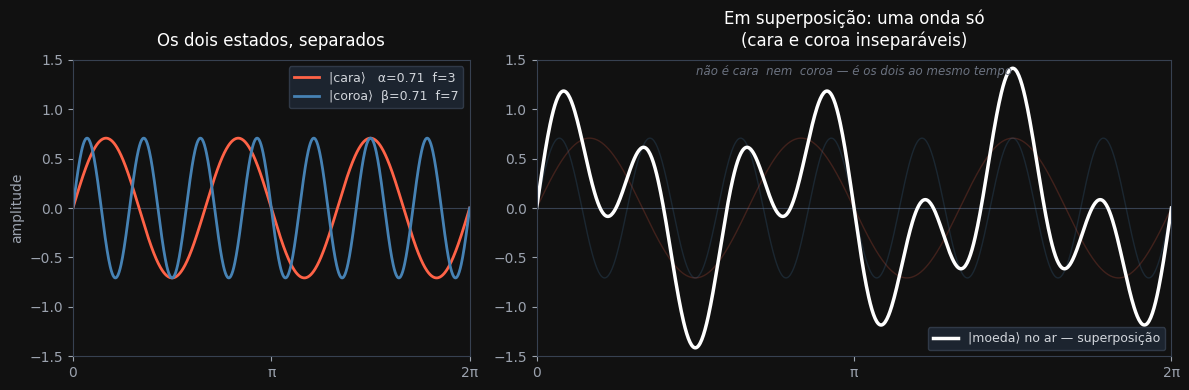

In [1]:
import numpy as np
import matplotlib.pyplot as plt

alpha = beta = 1 / np.sqrt(2)   # mesma amplitude — mesma probabilidade (50/50)
f_cara, f_coroa = 3, 7          # frequências distintas — "assinaturas" diferentes

t       = np.linspace(0, 2 * np.pi, 800)
w_cara  = alpha * np.sin(f_cara  * t)
w_coroa = beta  * np.sin(f_coroa * t)
superposicao = w_cara + w_coroa

fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#111',
                         gridspec_kw={'width_ratios': [1, 1.6]})
fig.patch.set_facecolor('#111')

for ax in axes:
    ax.set_facecolor('#111')
    ax.tick_params(colors='#9ca3af')
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels(['0', 'π', '2π'], color='#9ca3af')
    ax.axhline(0, color='#374151', lw=0.8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')

# ── Painel esquerdo: os dois componentes separados ───────────────────────────
ax = axes[0]
ax.plot(t, w_cara,  color='tomato',    lw=2, label=f'|cara⟩   α={alpha:.2f}  f={f_cara}')
ax.plot(t, w_coroa, color='steelblue', lw=2, label=f'|coroa⟩  β={beta:.2f}  f={f_coroa}')
ax.set_ylim(-1.5, 1.5)
ax.set_ylabel('amplitude', color='#9ca3af')
ax.set_title('Os dois estados, separados', color='white', pad=10)
ax.legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')

# ── Painel direito: a superposição — uma coisa só ────────────────────────────
ax = axes[1]
ax.plot(t, w_cara,       color='tomato',    lw=1, alpha=0.2)
ax.plot(t, w_coroa,      color='steelblue', lw=1, alpha=0.2)
ax.plot(t, superposicao, color='white',     lw=2.5, label='|moeda⟩ no ar — superposição')
ax.set_ylim(-1.5, 1.5)
ax.set_title('Em superposição: uma onda só\n(cara e coroa inseparáveis)', color='white', pad=10)
ax.legend(fontsize=9, labelcolor='#d1d5db', facecolor='#1f2937', edgecolor='#374151')
ax.text(np.pi, 1.35,
        'não é cara  nem  coroa — é os dois ao mesmo tempo',
        ha='center', color='#6b7280', fontsize=8.5, style='italic')

plt.tight_layout()
plt.show()

Agora sim, você vê que esses dois estados — que são meramente duas frequências possíveis de onda 3 ou 7 — quando somadas criam uma outra coisa que é uma onda só! Não é possível distinguir em nenhum momento nenhuma das duas ondas originais, isto é, nenhum dos estados iniciais.

## 3. Provocar Interferência

Agora, suponha que, durante a superposição, você pudesse interferir com apenas uma das ondas. Como se, ao olhar para a moeda no ar, você conseguisse fazer "cara" ter maior probabilidade de sair. Quando você a jogou, não havia diferença entre cara e coroa, ambas podederiam cair com a mesma probabilidade, mas você faz uma mágina e *voilà*: só cai cara! 

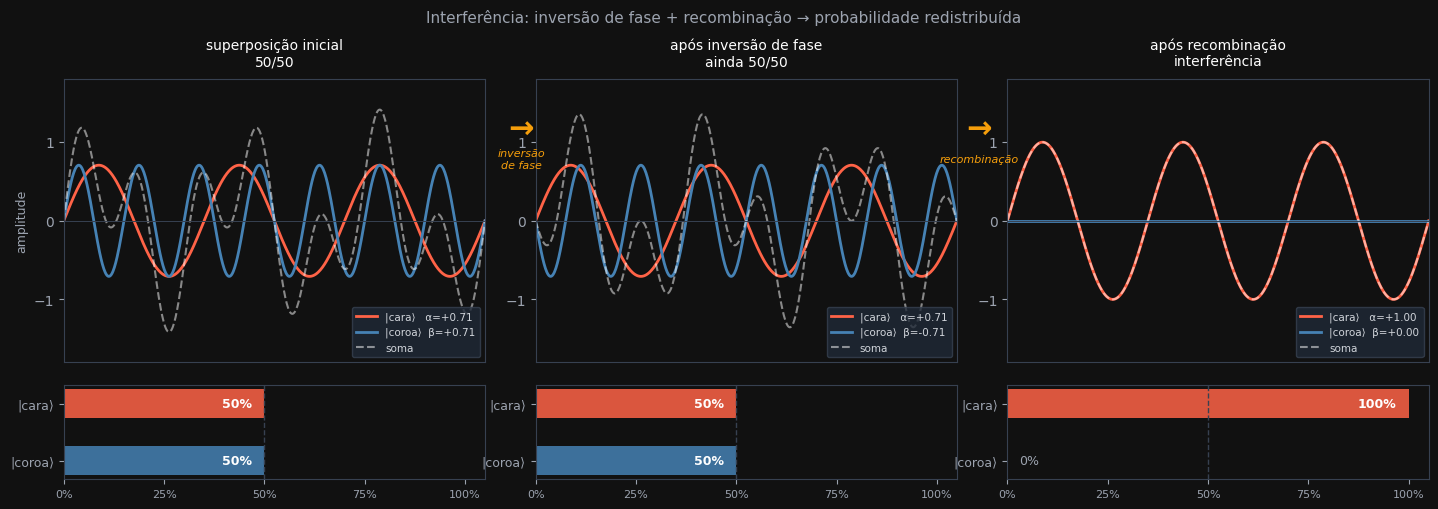

In [2]:
import numpy as np
import matplotlib.pyplot as plt

f_cara, f_coroa = 3, 7
t = np.linspace(0, 2 * np.pi, 600)

def ondas(a, b):
    return a * np.sin(f_cara * t), b * np.sin(f_coroa * t)

a1, b1 =  1/np.sqrt(2),  1/np.sqrt(2)   # superposição inicial
a2, b2 =  1/np.sqrt(2), -1/np.sqrt(2)   # inversão de fase em coroa
a3 = (a2 - b2) / np.sqrt(2)             # recombinação → 1  (cara = 100%)
b3 = (a2 + b2) / np.sqrt(2)             # recombinação → 0

etapas = [
    (a1, b1, 'superposição inicial\n50/50'),
    (a2, b2, 'após inversão de fase\nainda 50/50'),
    (a3, b3, 'após recombinação\ninterferência'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 5), facecolor='#111',
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.12, 'wspace': 0.12})
fig.patch.set_facecolor('#111')

for ax in axes.flat:
    ax.set_facecolor('#111')
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')
    ax.tick_params(colors='#9ca3af')

for col, (a, b, titulo) in enumerate(etapas):
    ax = axes[0, col]
    wc, wco = ondas(a, b)
    ax.plot(t, wc,       color='tomato',    lw=2,   label=f'|cara⟩   α={a:+.2f}')
    ax.plot(t, wco,      color='steelblue', lw=2,   label=f'|coroa⟩  β={b:+.2f}')
    ax.plot(t, wc + wco, color='white',     lw=1.5, ls='--', alpha=0.5, label='soma')
    ax.axhline(0, color='#374151', lw=0.7)
    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(-1.8, 1.8)
    ax.set_xticks([])
    ax.set_yticks([-1, 0, 1])
    ax.set_title(titulo, color='white', fontsize=10, pad=10)
    ax.legend(fontsize=7.5, labelcolor='#d1d5db', facecolor='#1f2937',
              edgecolor='#374151', loc='lower right')

axes[0, 0].set_ylabel('amplitude', color='#9ca3af', fontsize=9)

for i, operacao in enumerate(['inversão\nde fase', 'recombinação']):
    fig.text(0.365 + i * 0.305, 0.78, '→', color='#f59e0b', fontsize=22,
             ha='center', va='center', fontweight='bold')
    fig.text(0.365 + i * 0.305, 0.72, operacao, color='#f59e0b', fontsize=8,
             ha='center', va='center', fontstyle='italic')

for col, (a, b, _) in enumerate(etapas):
    ax = axes[1, col]
    pc, pco = a**2, b**2
    ax.barh(['|coroa⟩', '|cara⟩'], [pco, pc],
            color=['steelblue', 'tomato'], alpha=0.85, height=0.5)
    ax.axvline(0.5, color='#374151', lw=1, ls='--')
    ax.set_xlim(0, 1.05)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'], color='#9ca3af', fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['|coroa⟩', '|cara⟩'], color='#9ca3af', fontsize=9)
    for val, y_pos in [(pc, 1), (pco, 0)]:
        if val > 0.08:
            ax.text(val - 0.03, y_pos, f'{val:.0%}', va='center', ha='right',
                    color='white', fontsize=9, fontweight='bold')
        else:
            ax.text(val + 0.03, y_pos, f'{val:.0%}', va='center', ha='left',
                    color='#9ca3af', fontsize=9)

plt.suptitle(
    'Interferência: inversão de fase + recombinação → probabilidade redistribuída',
    color='#9ca3af', fontsize=11, y=1.02
)
plt.subplots_adjust(left=0.06, right=0.97, top=0.88, bottom=0.08)
plt.show()

Avaliando essa imagem da esquerda para a direita: no segundo painel, a onda azul foi refletida no eixo $x$ — isso é uma `inversão de fase`. Note que as barras de probabilidade continuam 50/50: inverter o sinal não altera o tamanho da amplitude — a "grossura da onda" —, só a direção. No terceiro painel, uma operação de recombinação soma as duas amplitudes. Onde os sinais concordam, a probabilidade se acumula; onde discordam, se anula. A probabilidade total se conserva, mas foi redistribuída. Isso é interferência.

Mas uma coisa essa imagem não explica: eu queria que "cara" fosse o resultado, inverti a fase de "coroa", recombinei — e cara ganhou. Mas por que inverter a fase de coroa favoreceu cara, e não o contrário? O que exatamente na recombinação fez a probabilidade ir para o lado certo? e afinal de contas, como exatamente eu consegui inverter a fase de coroa para início de conversa? fica para o próximo notebook.

## 4. Aplicar Operações Unitárias

Bom, tanto a inversão de fase quanto a recombinação que fizemos acima são `operações unitárias`. Você operou as amplitudes enquanto elas estavam em superposição — isto é, enquanto estavam somadas projetando a onda tracejada no fundo. Você aplicou duas operações: uma que inverteu o sinal, outra que recombinou. Ainda não sabemos o que elas são efetivamente nem como são realizadas fisicamente. Por hora, nos contentamos em entender que elas aconteceram e que juntas produziram a interferência.

Uma coisa importante sobre essas operações: elas são `reversíveis`. Precisam ser, porque se destruíssem informação no caminho (o que significa ser irreversível), as amplitudes se perderiam e não haveria o que interferir no final. A conservação da probabilidade total que você viu no gráfico — 50/50 virou 100/0, mas a soma continuou 1 — é consequência direta disso.

## 5. Codificar Soluções

No exemplo que fizemos, as soluções candidatas eram "cara" e "coroa" — e elas já eram naturalmente os dois estados do qubit. Mas num problema real, você precisa mapear as candidatas para estados de qubits. A quantidade de qubits define quantas candidatas cabem: 
- 1 qubit carrega 2
- 2 qubits carregam 4
- 3 carregam 8

... e assim por diante, sempre 2ⁿ. `Codificar soluções` é isso: traduzir o espaço de candidatas do seu problema para estados de qubits, de modo que todas possam entrar em superposição e participar da interferência. Como exatamente se faz essa tradução para problemas reais é assunto para outro momento.

## 6. O que este notebook te respondeu

Você entendeu que é possível usar uma abstração chamada `qubit`, que na prática é alguma forma de sistema físico, para computar soluções de um dado problema. Você faz isso `codificando` todas as possibilidades de solução. Essa codificação permiter preparar elas em `superposição` — ou seja, todas estão manifestadas ao mesmo tempo —, o que te permite aplicar `operações unitárias` sobre todas ao mesmo tempo. Essas operações fazem as `amplitudes interferirem` entre si de modo que, na medição, a resposta correta seja favorecida.

## 7. O que este notebook não respondeu

Próximo capítulo do núcleo:

- O que é uma operação unitária formalmente  — [N-01](../digressoes/N-01.ipynb)
- Por que o módulo ao quadrado de uma amplitude dá uma probabilidade — [N-01](../digressoes/N-01.ipynb)
- Por que as amplitudes precisam ser complexas e não apenas reais com sinal — [N-01](../digressoes/N-01.ipynb)
- Como, exatamente, eu codifico uma solução — [N-02](../digressoes/N-02.ipynb)
- Como se constrói a operação que inverte a fase da resposta certa sem saber qual é a resposta certa — [N-02](../digressoes/N-02.ipynb)
- Por que a recombinação redistribui a probabilidade para o lado correto e não para o errado — [N-02](../digressoes/N-02.ipynb)

Digressão:

- O que é um qubit fisicamente — [D-00](../digressoes/D-00.ipynb)
- Quando interferência é suficiente para dar vantagem computacional — [D-00](../digressoes/).